In [1]:
import numpy as np
import pandas as pd
import os,sys,glob
%load_ext autoreload
%autoreload 2
import plotting_helpers as helper
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import scipy
import nilearn
from scipy.spatial.distance import cdist, pdist, squareform


# adult rest movie surface plots

In [ ]:
methods = ['TPHATE_DiffOp_IDE','TPHATE_optt','MiND_ML','lPCA',"PCA",'MLE']
tasks = ['aeronaut','mickey','rest']
for m in methods:
    data_files = sorted(glob.glob(f'adult_restmovie/results/*_{m}_average_results.nii.gz'))
    image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
    global_range = helper.get_global_value_range(data_files)
    outfn_main = f'main_plots/adult_restmovie_{m}_searchlight.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'{m} restmovie',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)

main_plots/adult_restmovie_TPHATE_DiffOp_IDE_searchlight.png (0.0, 26)
Generated surface plot: adult_restmovie/plots/aeronaut_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: adult_restmovie/plots/mickey_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: adult_restmovie/plots/rest_TPHATE_DiffOp_IDE_average_plots.png
Compiled surface plots into grid: main_plots/adult_restmovie_TPHATE_DiffOp_IDE_searchlight.png
main_plots/adult_restmovie_TPHATE_optt_searchlight.png (0.0, 15)
Generated surface plot: adult_restmovie/plots/aeronaut_TPHATE_optt_average_plots.png
Generated surface plot: adult_restmovie/plots/mickey_TPHATE_optt_average_plots.png
Generated surface plot: adult_restmovie/plots/rest_TPHATE_optt_average_plots.png
Compiled surface plots into grid: main_plots/adult_restmovie_TPHATE_optt_searchlight.png
main_plots/adult_restmovie_MiND_ML_searchlight.png (0.0, 10)
Generated surface plot: adult_restmovie/plots/aeronaut_MiND_ML_average_plots.png
Generated surface plot

AssertionError: data_files list should not be empty.

In [7]:
methods = ['TPHATE_DiffOp_IDE','TPHATE_optt']
tasks = ['aeronaut','mickey']
for m in methods:
    data_files = sorted(glob.glob(f'adult_restmovie/results/*_{m}_average_results.nii.gz'))[:2]
    image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
    global_range = helper.get_global_value_range(data_files)
    outfn_main = f'main_plots/adult_restmovie_{m}_searchlight_movies.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'{m} restmovie',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)

main_plots/adult_restmovie_TPHATE_DiffOp_IDE_searchlight_movies.png (0.0, 18)
Generated surface plot: adult_restmovie/plots/aeronaut_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: adult_restmovie/plots/mickey_TPHATE_DiffOp_IDE_average_plots.png
Compiled surface plots into grid: main_plots/adult_restmovie_TPHATE_DiffOp_IDE_searchlight_movies.png
main_plots/adult_restmovie_TPHATE_optt_searchlight_movies.png (0.0, 13)
Generated surface plot: adult_restmovie/plots/aeronaut_TPHATE_optt_average_plots.png
Generated surface plot: adult_restmovie/plots/mickey_TPHATE_optt_average_plots.png
Compiled surface plots into grid: main_plots/adult_restmovie_TPHATE_optt_searchlight_movies.png


In [8]:
data_files = sorted(glob.glob(f'adult_restmovie/results/*ISC_average_results.nii.gz'))
image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
outfn_main = 'main_plots/adult_restmovie_ISC.png'
tasks=['aeronaut','mickey','rest']
helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=[0,0.5],
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f' ISC restmovie',
                                         rerun=True, 
                                         cbar_label='correlation',
                                         cmap='magma', 
                                         mask=True)

Generated surface plot: adult_restmovie/plots/aeronaut_ISC_average_plots.png
Generated surface plot: adult_restmovie/plots/mickey_ISC_average_plots.png
Generated surface plot: adult_restmovie/plots/rest_ISC_average_plots.png
Compiled surface plots into grid: main_plots/adult_restmovie_ISC.png


In [ ]:
ra_p = nib.load('adult_restmovie/results/rest_aeronaut_randomise_output_tfcs_corrp_tstat1.nii.gz')
ra_all = nib.load('adult_restmovie/results/rest_aeronaut_all_subjects.nii.gz')


# Infant rest movie surface plots

In [9]:
methods = ['TPHATE_DiffOp_IDE','TPHATE_optt','MiND_ML','lPCA',"PCA",'MLE']
tasks = ['aeronaut','mickey','sleep']
for m in methods:
    data_files = sorted(glob.glob(f'infant_restmovie/results/*_{m}_average_results.nii.gz'))
    image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
    global_range = helper.get_global_value_range(data_files)
    outfn_main = f'main_plots/infant_restmovie_{m}_searchlight.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'infants {m}',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)

main_plots/infant_restmovie_TPHATE_DiffOp_IDE_searchlight.png (0.0, 17)
Generated surface plot: infant_restmovie/plots/aeronaut_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: infant_restmovie/plots/mickey_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: infant_restmovie/plots/sleep_TPHATE_DiffOp_IDE_average_plots.png
Compiled surface plots into grid: main_plots/infant_restmovie_TPHATE_DiffOp_IDE_searchlight.png
main_plots/infant_restmovie_TPHATE_optt_searchlight.png (0.0, 0)
Generated surface plot: infant_restmovie/plots/aeronaut_TPHATE_optt_average_plots.png
Generated surface plot: infant_restmovie/plots/mickey_TPHATE_optt_average_plots.png
Generated surface plot: infant_restmovie/plots/sleep_TPHATE_optt_average_plots.png
Compiled surface plots into grid: main_plots/infant_restmovie_TPHATE_optt_searchlight.png
main_plots/infant_restmovie_MiND_ML_searchlight.png (0.0, 7)
Generated surface plot: infant_restmovie/plots/aeronaut_MiND_ML_average_plots.png
Generated 

In [2]:
methods = ['TPHATE_DiffOp_IDE']
tasks = ['aeronaut','mickey']
for m in methods:
    data_files = sorted(glob.glob(f'infant_restmovie/results/*_{m}_average_results.nii.gz'))[:2]
    image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
    global_range = helper.get_global_value_range(data_files)
    outfn_main = f'main_plots/infant_restmovie_{m}_searchlight.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'infants {m}',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)

main_plots/infant_restmovie_TPHATE_DiffOp_IDE_searchlight.png (0.0, 12)
Generated surface plot: infant_restmovie/plots/aeronaut_TPHATE_DiffOp_IDE_average_plots.png
Generated surface plot: infant_restmovie/plots/mickey_TPHATE_DiffOp_IDE_average_plots.png
Compiled surface plots into grid: main_plots/infant_restmovie_TPHATE_DiffOp_IDE_searchlight.png


In [3]:
data_files = sorted(glob.glob(f'infant_restmovie/results/*ISC_average_results.nii.gz'))
image_files = [df.replace('results','plots').replace('.nii.gz','.png') for df in data_files]
outfn_main = 'main_plots/infant_restmovie_ISC.png'
tasks=['aeronaut','mickey','sleep']
helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='searchlight',
                                         cbar_range=[0,0.3],
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'infant ISC restmovie',
                                         rerun=True, 
                                         cbar_label='correlation',
                                         cmap='magma', 
                                         mask=True)

Generated surface plot: infant_restmovie/plots/aeronaut_ISC_average_plots.png
Generated surface plot: infant_restmovie/plots/mickey_ISC_average_plots.png
Generated surface plot: infant_restmovie/plots/sleep_ISC_average_plots.png
Compiled surface plots into grid: main_plots/infant_restmovie_ISC.png


# partly cloudy surface plots

In [ ]:
methods = ['MLE']#['TPHATE_DiffOp_IDE','TPHATE_optt','MiND_ML','lPCA',"PCA",'MLE']
fns = sorted(glob.glob('partlycloudy/results/*TPHATE_DiffOp_IDE*average*atlas.npy'))
groups = [os.path.basename(f).split('_')[3] for f in fns]
print(groups)
for m in methods:
    data_files = sorted(glob.glob(f'partlycloudy/results/*_{m}_average_results_atlas.npy'))
    image_files = [df.replace('results','plots').replace('.npy','.png') for df in data_files]
    try:
        global_range = helper.get_global_value_range(data_files)
    except:
        print(f'failed on {m}'); continue
    global_range=(0,global_range[1])
    if m == 'TPHATE_DiffOp_IDE':
        global_range=(0,15)
    outfn_main = f'main_plots/partlycloudy_{m}_atlas.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='Schaefer',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=groups,
                                         main_title=f'partly cloudy {m}',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)

['3yo', '4yo', '5yo', '7yo', '8-12yo', 'Adult']
main_plots/partlycloudy_TPHATE_DiffOp_IDE_atlas.png (0, 15)
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: partlycloudy/plots/pixar_subject_filter_3yo_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: partlycloudy/plots/pixar_subject_filter_4yo_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: partlycloudy/plots/pixar_subject_filter_5yo_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: partlycloudy/plots/pixar_subject_filter_7yo_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: par

: 

# narratives

In [15]:
methods = ['TPHATE_DiffOp_IDE','PCA','ISC']#['TPHATE_DiffOp_IDE','TPHATE_optt','MiND_ML','lPCA',"PCA",'MLE']
tasks = ['black','bronx','forgot','piemanpni']
for m in methods:
    data_files = sorted(glob.glob(f'narratives/results/*_{m}_average_results_atlas.npy'))
    image_files = [df.replace('results','plots').replace('.npy','.png') for df in data_files]
    try:
        global_range = helper.get_global_value_range(data_files)
    except:
        print(f'failed on {m}; continue');continue
    if m =='TPHATE_DiffOp_IDE':
        global_range=(0, 20)
    global_range = (0, global_range[1])
    if m == 'ISC':
        global_range = (0, 0.5)
    outfn_main = f'main_plots/narratives_{m}_atlas.png'
    print(outfn_main, global_range)
    helper.compile_surface_plots_to_grid(data_files=data_files, 
                                         image_files=image_files, 
                                         output_path=outfn_main, 
                                         atlas='Schaefer',
                                         cbar_range=global_range,
                                         target_density='32k',
                                         surf_type='fslr', 
                                         method='nearest',
                                         titles=tasks,
                                         main_title=f'{m}',
                                         rerun=True, 
                                         cbar_label='intrinsic dimensionality',
                                         cmap='magma', 
                                         mask=True)
                                         
    plt.close()

main_plots/narratives_TPHATE_DiffOp_IDE_atlas.png (0, 20)
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: narratives/plots/black_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: narratives/plots/bronx_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: narratives/plots/forgot_TPHATE_DiffOp_IDE_average_plots_atlas.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: narratives/plots/piemanpni_TPHATE_DiffOp_IDE_average_plots_atlas.png
Compiled surface plots into grid: main_plots/narratives_TPHATE_DiffOp_IDE_atlas.png
main_plots/narratives_PCA_atlas.png (0, 54)
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: narr

In [27]:
# Load in the ISC data for the narratives
isc_data = np.vstack([np.load(f) for f in sorted(glob.glob(f'narratives/results/*ISC*average_results_atlas.npy'))] )
ide_data = np.vstack([np.load(f) for f in sorted(glob.glob(f'narratives/results/*_TPHATE_VNE_IDE_average_results_atlas.npy'))])

<Axes: >

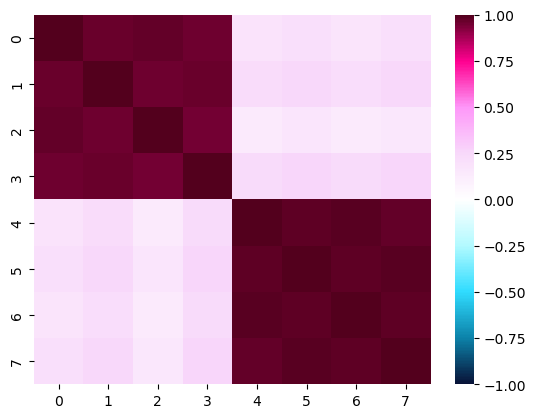

In [30]:
sns.heatmap(np.corrcoef(isc_data.T, ide_data.T, rowvar=False),cmap=helper.diverging_colormap_bp(), vmin=-1, vmax=1)

In [32]:
t.shape

(1000, 100)

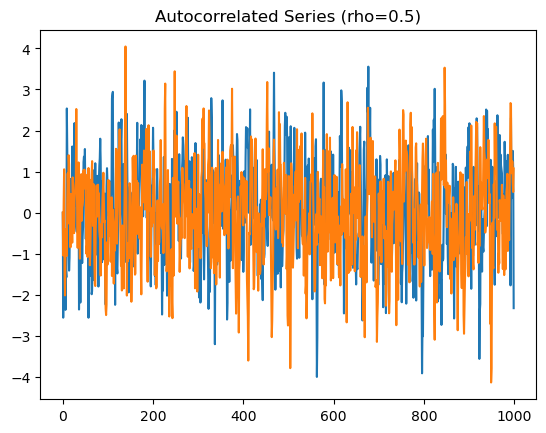

In [68]:

def generate_autocorrelated_series(length=1000, rho=0.5, random_state=None):
    """
    Generate an AR(1) process with specified autocorrelation (rho).
    """
    rng = np.random.default_rng(random_state)
    x = np.zeros(length)
    noise = rng.normal(size=length)
    for t in range(1, length):
        x[t] = rho * x[t-1] + noise[t]
    return x

x1 = generate_autocorrelated_series(length=1000, rho=0.5,random_state=3)
x2= generate_autocorrelated_series(length=1000, rho=0.5, random_state=42)
plt.plot(x1, label='Series 1')
plt.plot(x2, label='Series 2')
plt.title("Autocorrelated Series (rho=0.5)")
plt.show()



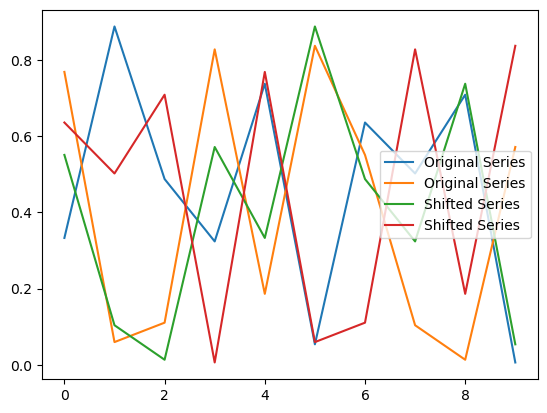

In [66]:
x1 = np.random.random((10, 2))
x1_roll = np.roll(x1.T, 4).T
plt.plot(x1, label='Original Series')
plt.plot(x1_roll, label='Shifted Series')
plt.legend()

In [90]:
x1 = np.random.random((10, 100))
rng = np.random.default_rng(random_state)
noise = rng.normal(size=x1.shape)

x2 = x1 + noise

In [91]:
np.corrcoef(x1.ravel(), x2.ravel()) 

array([[1.        , 0.28496838],
       [0.28496838, 1.        ]])

In [92]:
import stats_helper
stats_helper.timeseries_correlation_permutation(x1, x2, n_permute=1000)

{'spearmanr': 0.2803857283857284,
 'pearsonr': 0.2849683786972957,
 'kendalltau': 0.1901901901901902,
 'p': 0.001998001998001998}

In [ ]:
corrs = [scipy.stats.pearsonr(x1, np.roll(x1, i))[0] for i in range(100)]
corrs 

[1.0,
 0.496046243449805,
 0.257039628019338,
 0.12407370681485926,
 0.07708708292062916,
 0.05130202614873648,
 -0.004385491918282612,
 0.0238562564883116,
 -0.017104196945517222,
 -0.01893136759950608,
 -0.021126521388585607,
 0.005940994557234911,
 -0.006086990851720837,
 -0.04518936532585336,
 -0.038768032446361164,
 -0.05015064048828372,
 0.007953961492771488,
 0.010261083213093687,
 0.023841844203805147,
 0.0008444422126870784,
 0.03342791436168842,
 0.055755693855255035,
 -0.0072333745420344415,
 0.017738573936678666,
 0.016981570313054327,
 0.004620753547544073,
 -0.013991022023054401,
 -0.04459269357850097,
 -0.04758859862932588,
 -0.08098870090005514,
 -0.06045596195412738,
 -0.06894424280111454,
 -0.044610201444029884,
 -0.031049837516138133,
 -0.05122809421066413,
 -0.013382730417646673,
 -0.028332558658979885,
 0.03267335142934495,
 -0.005205622539883541,
 -0.015537763717981526,
 -0.0015050705204756076,
 0.014565522637078476,
 0.03537516214453775,
 0.02767916354190842,
 0.

Error plotting line for subject 39, stimulus black: x and y must have same first dimension, but have shapes (3,) and (0,)


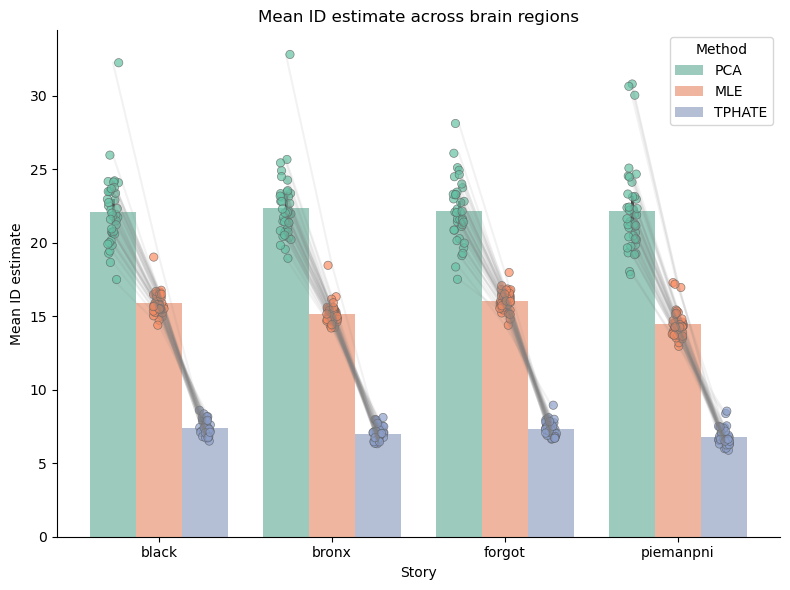

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.barplot(data=df, x='stimulus', y='mean_value', hue='method', alpha=0.7, palette=palette)
sns.stripplot(data=df, x='stimulus', y='mean_value', hue='method', 
              dodge=True, marker='o', alpha=0.7, linewidth=0.5, size=6, palette=palette)

# Remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
n_methods = len(methods)
plt.legend(handles[:n_methods], labels[:n_methods], title='Method')

# Get the positions of each bar for each hue (method) within each stimulus
xticks = ax.get_xticks()
width = 0.8 / n_methods  # default bar width divided by number of hues

# Build a mapping from (stimulus, method) to x position
stimulus_to_num = {stim: i for i, stim in enumerate(stimuli)}
method_to_num = {method: i for i, method in enumerate(methods)}

for subj in df['subject'].unique():
    subj_df = df[df['subject'] == subj]
    for stim in stimuli:
        row = subj_df[subj_df['stimulus'] == stim]
        # Sort by method for consistent line plotting
        # row = row.set_index('method').loc[methods].reset_index()
        xvals = []
        for method in methods:
            stim_idx = stimulus_to_num[stim]
            method_idx = method_to_num[method]
            # Calculate the x position for this method within this stimulus
            x = xticks[stim_idx] - 0.4 + width/2 + method_idx*width
            xvals.append(x)
        try:
            plt.plot(xvals, row['mean_value'].values, color='gray', alpha=0.1, zorder=20)
        except Exception as e:
            print(f"Error plotting line for subject {subj}, stimulus {stim}: {e}")

# Remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
n_methods = len(methods)
plt.legend(handles[:n_methods], labels[:n_methods], title='Method')
sns.despine()
plt.ylabel('Mean ID estimate')
plt.xlabel('Story')
plt.title('Mean ID estimate across brain regions')
plt.tight_layout()
plt.show()

# Stats 

In [6]:
from nilearn.glm.second_level import non_parametric_inference
from nilearn import image

def compute_task_differences_paired(task1, task2, n_perm=1000, threshold=None, two_sided_test=True, n_jobs=1):
    """
    Compute paired differences between two lists of Nifti images and perform non-parametric inference
    with cluster-level multiple comparison correction.

    Parameters
    ----------
    task1_imgs : list of str or nibabel.Nifti1Image
        List of Nifti images for task 1.
    task2_imgs : list of str or nibabel.Nifti1Image
        List of Nifti images for task 2 (same length/order as task1_imgs).
    n_perm : int
        Number of permutations for the test.
    threshold : float
        Cluster forming threshold (e.g., t > 2.0).
    two_sided_test : bool
        Whether to perform a two-sided test.
    n_jobs : int
        Number of parallel jobs.
    cluster_threshold : float
        Cluster-level FWE corrected p-value threshold.

    Returns
    -------
    stat_img : nibabel.Nifti1Image
        Map of test statistics.
    pval_img : nibabel.Nifti1Image
        Map of corrected p-values.
    """
    # If input is a single Nifti image, treat as 4D
    if isinstance(task1, (str, nib.Nifti1Image)) and isinstance(task2, (str, nib.Nifti1Image)):
        if isinstance(task1, str):
            task1 = nib.load(task1)
        if isinstance(task2, str):
            task2 = nib.load(task2)
        # Check if 4D
        if task1.ndim == 4 and task2.ndim == 4:
            assert task1.shape == task2.shape, "4D images must have the same shape"
            n_subj = task1.shape[3]
            task1_imgs = [image.index_img(task1, i) for i in range(n_subj)]
            task2_imgs = [image.index_img(task2, i) for i in range(n_subj)]
        else:
            raise ValueError("If passing Nifti images, they must be 4D (participants in 4th dim)")
    else:
        # Assume lists of images
        task1_imgs = task1
        task2_imgs = task2
        assert len(task1_imgs) == len(task2_imgs), "Input lists must have the same length."

    # Compute paired differences
    diff_imgs = []
    for img1, img2 in zip(task1_imgs, task2_imgs):
        diff_imgs.append(image.math_img('img1 - img2', img1=img1, img2=img2))
    design_mtx = pd.DataFrame(data={'intercept': np.ones(len(diff_imgs))})
    # Run non-parametric inference
    outputs= non_parametric_inference(
        diff_imgs,
        design_matrix= design_mtx,
        model_intercept=True,
        n_perm=n_perm,
        two_sided_test=two_sided_test,
        threshold=threshold,
        n_jobs=n_jobs,
        mask=None,
        smoothing_fwhm=None,
        tfce=True,
        verbose=1,
    )
    return outputs,diff_imgs




In [7]:
task0 = nib.load('adult_restmovie/results/aeronaut_TPHATE_DiffOp_IDE_all_subjects_results.nii.gz')
task1 = nib.load('adult_restmovie/results/rest_TPHATE_DiffOp_IDE_all_subjects_results.nii.gz')
outputs=compute_task_differences_paired(task1, task0,  n_perm=1000, two_sided_test=False, n_jobs=-1)

[non_parametric_inference] Fitting second level model...
[non_parametric_inference] 
Computation of second level model done in 0.33997130393981934 seconds



In [5]:
import numpy as np
import nibabel as nib

def mask_stat_img_with_pval(stat_img, pval_img, alpha=0.05, log10_pval=False):
    """
    Mask a statistical image with a p-value image, setting voxels to 0 where p >= alpha.
    If log10_pval is True, pval_img is assumed to be -log10(p) and will be converted.

    Parameters
    ----------
    stat_img : nibabel.Nifti1Image
        Statistical image (e.g., t or z map).
    pval_img : nibabel.Nifti1Image
        P-value image (same shape as stat_img).
    alpha : float
        Significance threshold.
    log10_pval : bool
        If True, pval_img is in -log10(p) scale.

    Returns
    -------
    masked_img : nibabel.Nifti1Image
        Masked statistical image.
    """
    stat_data = stat_img.get_fdata()
    pval_data = pval_img.get_fdata()
    if log10_pval:
        # Convert -log10(p) to p
        pval_data = 10 ** (-pval_data)
    masked_data = np.where(pval_data < alpha, stat_data, 0)
    print(np.sum(masked_data!=0))
    return nib.Nifti1Image(masked_data, stat_img.affine, stat_img.header)


In [9]:
hex = ["#ED5151",'#FE7F2D', '#FCCA46', '#A1C181', '#47A8BD','#B47BBF',"#FF91E7"]
palette = sns.color_palette(hex)
palette

[(0.9294117647058824, 0.3176470588235294, 0.3176470588235294),
 (0.996078431372549, 0.4980392156862745, 0.17647058823529413),
 (0.9882352941176471, 0.792156862745098, 0.27450980392156865),
 (0.6313725490196078, 0.7568627450980392, 0.5058823529411764),
 (0.2784313725490196, 0.6588235294117647, 0.7411764705882353),
 (0.7058823529411765, 0.4823529411764706, 0.7490196078431373),
 (1.0, 0.5686274509803921, 0.9058823529411765)]

In [ ]:
helper.generate_surface_plot(np.arange(1,401), '', 'Schaefer', "magma", [1,10], surf_type='fsaverage', 
                             target_density='41k',include_cbar=True, method='nearest')


[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018


AssertionError: 

In [71]:
import numpy as np
from scipy.stats import wilcoxon, ttest_1samp, ttest_rel
from statsmodels.stats.multitest import multipletests

def paired_difference_nonparametric(arr1, arr2, alpha=0.05, alternative='greater'):
    """
    Compute within-sample differences, test if difference > 0 using Wilcoxon signed-rank test,
    and apply Benjamini-Hochberg FDR correction.

    Parameters
    ----------
    arr1, arr2 : np.ndarray, shape (N, M)
        Paired data arrays (N samples, M features).
    alpha : float
        FDR threshold for significance.

    Returns
    -------
    mean_diff : np.ndarray, shape (M,)
        Mean difference (arr1 - arr2) for each feature.
    pvals : np.ndarray, shape (M,)
        P-values from Wilcoxon signed-rank test for each feature.
    sig_mask : np.ndarray, shape (M,)
        Boolean array, True if FDR-corrected p < alpha.
    """
    arr1 = np.asarray(arr1)
    arr2 = np.asarray(arr2)
    assert arr1.shape == arr2.shape, "Arrays must have the same shape"
    N, M = arr1.shape

    mean_diff = np.mean(arr1 - arr2, axis=0)
    pvals = np.zeros(M)
    for i in range(M):
        stat, p = ttest_rel(arr1[:, i], arr2[:, i], alternative=alternative)
        pvals[i] = p

    # Benjamini-Hochberg FDR correction
    reject, pvals_corr, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    sig_mask = reject

    return mean_diff, pvals, sig_mask


def paired_difference_permutation(arr1, arr2, alpha=0.05, n_perm=1000, random_state=None,alternative='greater'):
    """
    Compute within-sample differences, test if difference > 0 using a permutation test,
    and apply Benjamini-Hochberg FDR correction.

    Parameters
    ----------
    arr1, arr2 : np.ndarray, shape (N, M)
        Paired data arrays (N samples, M features).
    alpha : float
        FDR threshold for significance.
    n_perm : int
        Number of permutations.
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    mean_diff : np.ndarray, shape (M,)
        Mean difference (arr1 - arr2) for each feature.
    pvals : np.ndarray, shape (M,)
        P-values from permutation test for each feature.
    sig_mask : np.ndarray, shape (M,)
        Boolean array, True if FDR-corrected p < alpha.
    """
    rng = np.random.default_rng(random_state)
    arr1 = np.asarray(arr1)
    arr2 = np.asarray(arr2)
    assert arr1.shape == arr2.shape, "Arrays must have the same shape"
    N, M = arr1.shape

    diffs = arr1 - arr2
    mean_diff = np.mean(diffs, axis=0)
    pvals = np.zeros(M)

    for i in range(M):
        observed = mean_diff[i]
        # Permutation: randomly flip sign of each paired difference
        perm_diffs = np.empty(n_perm)
        for p in range(n_perm):
            signs = rng.choice([1, -1], size=N)
            perm_diffs[p] = np.mean(diffs[:, i] * signs)
        if alternative == 'greater':
            pvals[i] = (np.sum(perm_diffs >= observed) + 1) / (n_perm + 1)
        elif alternative == 'less':
            pvals[i] = (np.sum(perm_diffs <= observed) + 1) / (n_perm + 1)
        elif alternative == 'two-sided':
            pvals[i] = (np.sum(np.abs(perm_diffs) >= np.abs(observed)) + 1) / (n_perm + 1)
        else:
            raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    reject, pvals_corr, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    sig_mask = reject

    return mean_diff, pvals, sig_mask

[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: 


('', <nibabel.nifti1.Nifti1Image at 0x7f4e8023d220>)

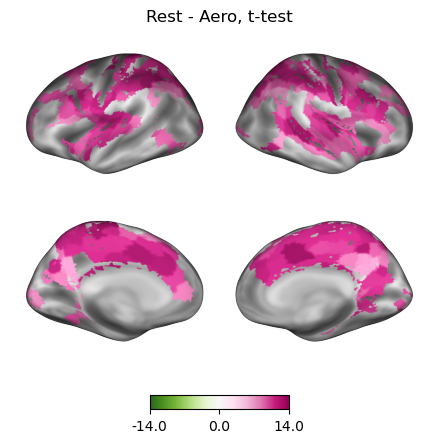

In [84]:
M = 'TPHATE_DiffOp_IDE'
arr1 = np.load(f'adult_restmovie/results/rest_{M}_all_subject_results_atlas.npy')
arr2 = np.load(f'adult_restmovie/results/aeronaut_{M}_all_subject_results_atlas.npy')
mean_diff, pvals, sig_mask = paired_difference_nonparametric(arr1, arr2, alpha=0.01,alternative='greater')
mean_diff_pperm, pvals_pperm, sig_mask_pperm = paired_difference_permutation(arr1, arr2, alpha=0.01, n_perm=1000,alternative='greater')
mean_diff_thresholded = np.where(sig_mask==True, mean_diff, np.nan)
mean_diff_pperm_thresholded = np.where(sig_mask_pperm==True, mean_diff_pperm, np.nan)
helper.generate_surface_plot(mean_diff_thresholded, '', 'Schaefer', 'PiYG_r', [-14,14], include_cbar=True, title='Rest - Aero, t-test')


[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: 


('', <nibabel.nifti1.Nifti1Image at 0x7f4ea5036a60>)

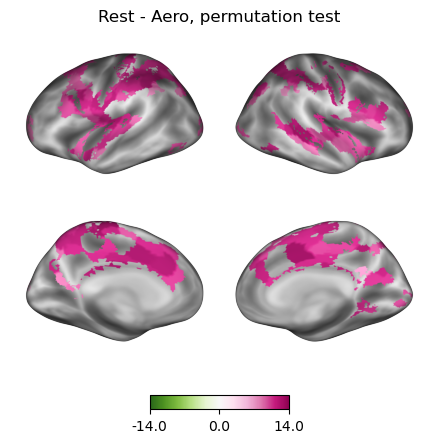

In [85]:
helper.generate_surface_plot(mean_diff_pperm_thresholded, '', 'Schaefer', 'PiYG_r', [-14,14], include_cbar=True, title='Rest - Aero, permutation test')

[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: 


('', <nibabel.nifti1.Nifti1Image at 0x7f4e828611c0>)

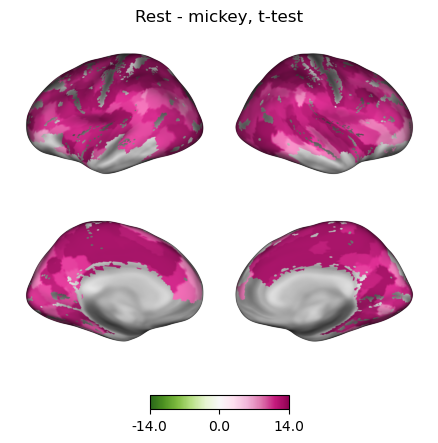

In [86]:
M = 'TPHATE_DiffOp_IDE'
arr1 = np.load(f'adult_restmovie/results/rest_{M}_all_subject_results_atlas.npy')
arr2 = np.load(f'adult_restmovie/results/mickey_{M}_all_subject_results_atlas.npy')
mean_diff, pvals, sig_mask = paired_difference_nonparametric(arr1, arr2, alpha=0.01,alternative='greater')
mean_diff_pperm, pvals_pperm, sig_mask_pperm = paired_difference_permutation(arr1, arr2, alpha=0.01, n_perm=1000,alternative='greater')
mean_diff_thresholded = np.where(sig_mask==True, mean_diff, np.nan)
mean_diff_pperm_thresholded = np.where(sig_mask_pperm==True, mean_diff_pperm, np.nan)
helper.generate_surface_plot(mean_diff_thresholded, '', 'Schaefer', 'PiYG_r', [-14,14], include_cbar=True, title='Rest - mickey, t-test')


[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: 


('', <nibabel.nifti1.Nifti1Image at 0x7f4e82861a60>)

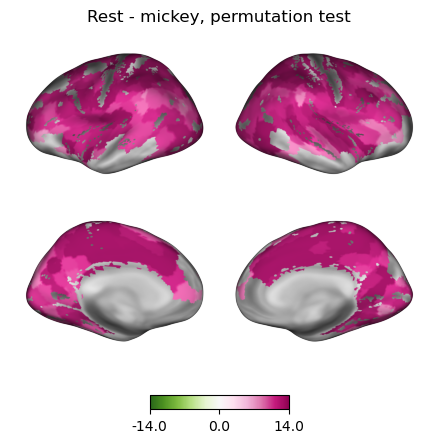

In [87]:
helper.generate_surface_plot(mean_diff_pperm_thresholded, '', 'Schaefer', 'PiYG_r', [-14,14], include_cbar=True, title='Rest - mickey, permutation test')